# Inspect tack placement (Phase 7)

`tackrule-0.1` (D38) drawn on every joint type and every curved family. A tack is a
**short weld**, not a point — each is drawn at its true `tack_length_mm` along the local
seam direction, and the small number next to it is its **scene-global weld order**
(ends → centre → bisect on open seams, opposite pairs on closed loops, same-class seams
interleaved round-robin — the heat-balance stagger).

What to look for:

* open seams start at the **margin** `max(2t, tack_len)`, never at the plate corner
* spacing sits inside `[10·t, min(33·t, 400)]` mm — the table at the bottom checks it
* closed loops: **even** count, first two welds **antipodal**, rotation set by the
  recorded D39 phase (`sha256(scene_id, seam_id)` — reruns land identically)
* a T's two fillets weld A0, B0, A1, B1, … — order numbers alternate sides
* a too-short seam collapses to ONE centre tack instead of nonsense

Runtime: the curved grid generates one scene per family — family 5 (rounded rect) is
the slow one (~1–2 min); trim `FAMILIES` if you are in a hurry. Run from `weld_generator/`.


In [1]:
import sys, numpy as np
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
from weldgen.config import load_config
from weldgen.scene import SceneRejected, generate_scene
from weldgen.scene_curved import generate_curved_scene
from weldgen.tacks import DEFAULT_PARAMS

CLR = ["#1f6f8b", "#b5453b", "#2f7d4f", "#8b5a1f", "#6b2f8b", "#4a6b1f"]
OBJ_CLR = ["#7aa6c2", "#c2857a", "#9dbf8e"]


def tack_scene(cfg, budget=40, start=0):
    """First emitting seed; routes on seam_families like the CLI."""
    gen = generate_curved_scene if cfg.get("seam_families") else generate_scene
    for seed in range(start, start + budget):
        try:
            return gen(cfg, seed)
        except SceneRejected:
            continue
    raise RuntimeError("no emitting seed - widen the budget")


def draw_tacks(ax, scene, arrays, annotate=True, max_pts=8000):
    """The parts (thinned cloud, coloured per object), primary seams (dark, thin),
    tacks at true length (thick, coloured by seam), weld-order rank annotated."""
    xyz = arrays["cloud.npz:xyz"].astype(float)
    oid = arrays["cloud.npz:object_id"]
    for o in np.unique(oid):
        m = oid == o
        step = max(1, int(m.sum()) // max_pts)
        ax.scatter(*xyz[m][::step].T, s=0.4, c=OBJ_CLR[int(o) % len(OBJ_CLR)],
                   alpha=0.5, linewidths=0)
    polys = {}
    for s in scene["seams"]:
        if not (s["weldable"] and s["matches_joint_type"]):
            continue
        q = arrays[f'seams.npz:{s["sampled"]["array"]}'].astype(float)
        polys[s["id"]] = q
        qq = np.vstack([q, q[:1]]) if s.get("closed") else q
        ax.plot(*qq.T, lw=1.4, c="#333333")
    tacks = scene["tacks"]
    pts = np.asarray(tacks["points_mm"], dtype=float)
    for j in range(len(pts)):
        poly = polys[tacks["seam_id"][j]]
        k = int(np.argmin(np.linalg.norm(poly - pts[j], axis=1)))
        a, b = poly[max(k - 1, 0)], poly[min(k + 1, len(poly) - 1)]
        d = b - a
        d /= max(np.linalg.norm(d), 1e-9)
        half = 0.5 * tacks["tack_length_mm"][j]
        seg = np.stack([pts[j] - half * d, pts[j] + half * d])
        ax.plot(*seg.T, lw=5, c=CLR[tacks["seam_id"][j] % len(CLR)],
                solid_capstyle="butt", zorder=5)
        if annotate:
            ax.text(*pts[j], f' {tacks["order"][j]}', fontsize=8, zorder=6)
    lo, hi = xyz.min(axis=0), xyz.max(axis=0)
    mid, span = 0.5 * (lo + hi), max(float((hi - lo).max()), 1.0)
    for k2, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        setter(mid[k2] - 0.55 * span, mid[k2] + 0.55 * span)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()


def rule_line(scene):
    t = scene["tacks"]["params"]["t_mm"]
    n = len(scene["tacks"]["seam_id"])
    return f't={t:.1f}mm  d in [{10*t:.0f}, {min(33*t, 400):.0f}]mm  {n} tacks'

## The five plate joint types

Generated from the `bench6a_*` presets with `emit_tacks: true` (the flag is opt-in per
config, so these scenes get a different `config_id` than the stored corpus — the
geometry twins are identical). Plates are drawn in **world** coordinates here: tack
geometry is frame-independent, and the curved panels below have no assembly frame anyway.


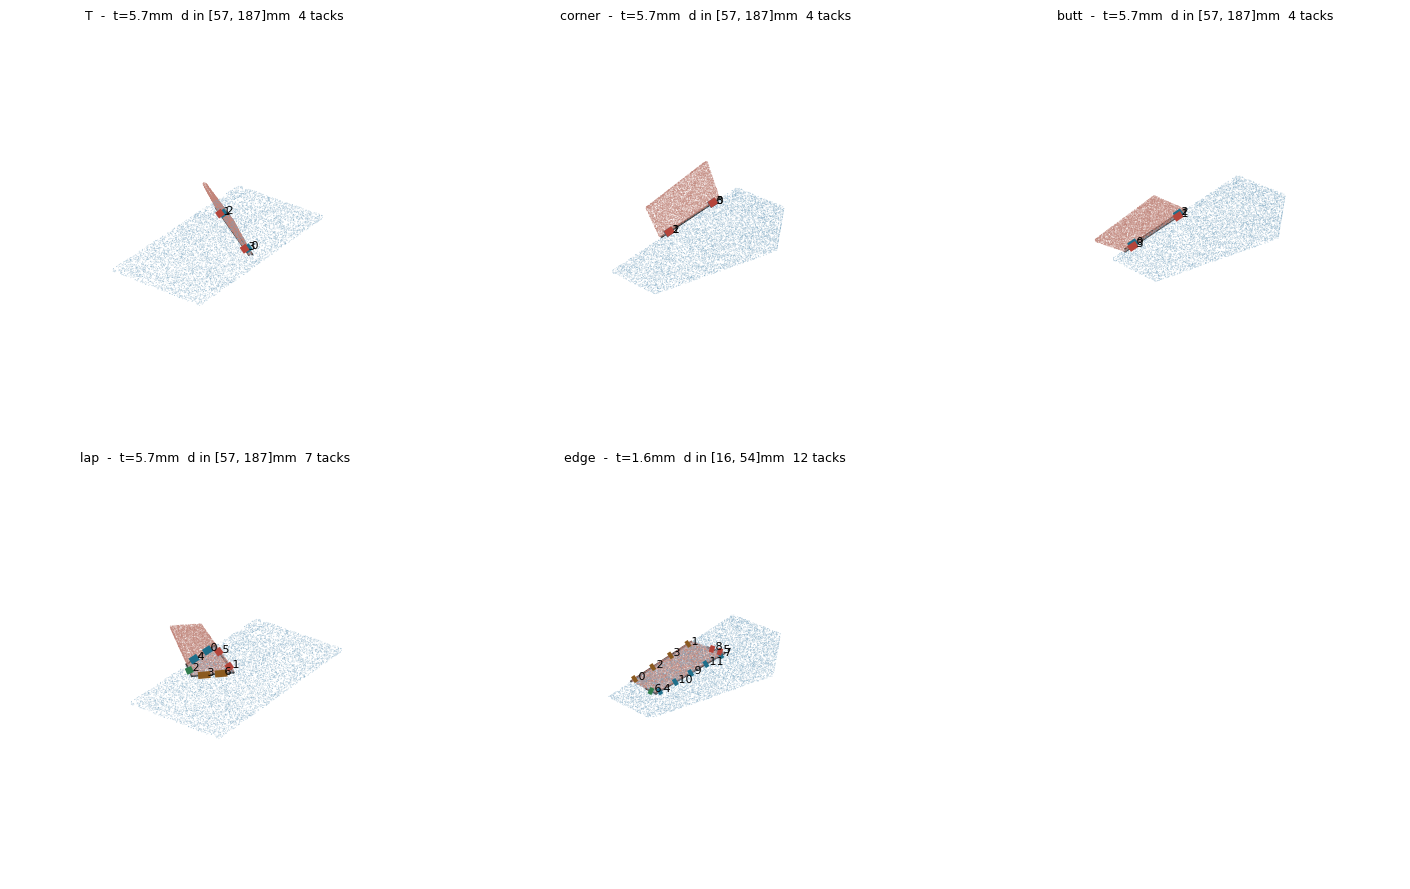

In [2]:
fig = plt.figure(figsize=(15, 9))
for i, jt in enumerate(("T", "corner", "butt", "lap", "edge")):
    cfg = load_config(f"../configs/bench6a_{jt}.yaml")
    cfg["emit_tacks"] = True
    scene, arrays = tack_scene(cfg)
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    draw_tacks(ax, scene, arrays)
    ax.set_title(f'{jt}  -  {rule_line(scene)}', fontsize=9)
plt.tight_layout()

## The six curved families

Closed loops (circle / ellipse / saddle / rounded rect) show the D39 phase and the
opposite-pair order; the open swept and arc seams show the margin + bisection order on
genuinely curved runs — the case that makes the tack label non-trivial.


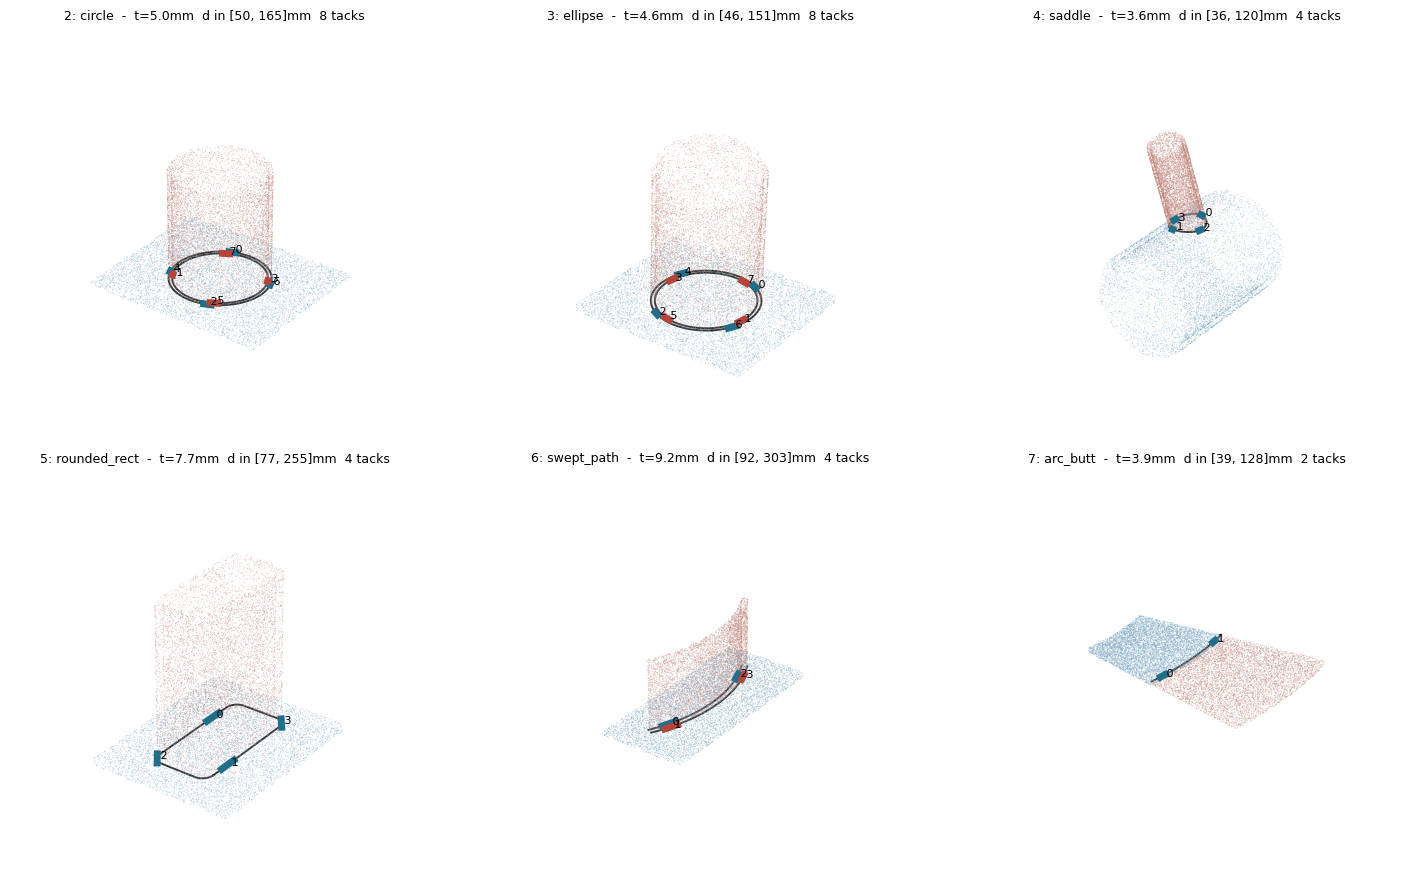

In [3]:
FAMILIES = [2, 3, 4, 5, 6, 7]     # 5 is the slow one (~1-2 min); trim if needed
NAMES = {2: "circle", 3: "ellipse", 4: "saddle", 5: "rounded_rect",
         6: "swept_path", 7: "arc_butt"}

fig = plt.figure(figsize=(15, 9))
for i, fam in enumerate(FAMILIES):
    cfg = load_config("../configs/curved_smoke.yaml")
    cfg["seam_families"] = [fam]
    cfg["emit_tacks"] = True
    scene, arrays = tack_scene(cfg)
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    draw_tacks(ax, scene, arrays)
    ax.set_title(f'{fam}: {NAMES[fam]}  -  {rule_line(scene)}', fontsize=9)
plt.tight_layout()

## The conventions, in numbers

Three spot checks that the drawings above imply: spacing inside the thickness-scaled
bounds with the end margin honoured; the closed-loop phase recorded and the first two
welds of **each ring's own sequence** antipodal; and the degenerate collapse — a butt
seam shorter than `2·margin + tack_len` gets exactly one centre tack.

One subtlety the pipe-on-plate scene teaches: it has **two** closed rings (the outer
fillet and the cleared bore fillet), and the scene-global order interleaves them — so
the antipodal pairing is a per-seam property that survives the round-robin, not a
property of global ranks 0 and 1.

In [4]:
# --- open seam: margins and spacing vs the bounds ---------------------------------
cfg = load_config("../configs/bench6a_butt.yaml"); cfg["emit_tacks"] = True
scene, arrays = tack_scene(cfg)
tk = scene["tacks"]; t = tk["params"]["t_mm"]
for sid in sorted(set(tk["seam_id"])):
    s = np.sort([a for a, i in zip(tk["arclength_mm"], tk["seam_id"]) if i == sid])
    L = next(x["length_mm"] for x in scene["seams"] if x["id"] == sid)
    gaps = np.diff(s)
    print(f'seam {sid}: L={L:.0f}  margin={s[0]:.1f} (rule {max(2*t, np.clip(4*t,10,50)):.1f})  '
          f'gaps {np.round(gaps,1)}  in [{10*t:.0f},{min(33*t,400):.0f}]: '
          f'{bool(len(gaps)==0 or (gaps.min()>=10*t-1e-6 and gaps.max()<=min(33*t,400)+1e-6))}')

# --- closed loops: recorded phase; each ring's OWN first pair is antipodal --------
cfg = load_config("../configs/curved_smoke.yaml")
cfg["seam_families"] = [2]; cfg["emit_tacks"] = True
scene_c, arrays_c = tack_scene(cfg)
tk = scene_c["tacks"]
s = np.asarray(tk["arclength_mm"])
ranked = np.argsort(tk["order"])
print(f'\nphases (D39, sha256-derived, recorded): {tk["params"]["phase_by_seam"]}')
print("global weld sequence by seam id:",
      [tk["seam_id"][i] for i in ranked])
for sid in sorted(set(tk["seam_id"])):
    own = [i for i in ranked if tk["seam_id"][i] == sid]   # this ring's own sequence
    L = next(x["length_mm"] for x in scene_c["seams"] if x["id"] == sid)
    gap = abs(s[own[0]] - s[own[1]]); gap = min(gap, L - gap)
    print(f'ring {sid}: n={len(own)} (even: {len(own) % 2 == 0}), first own pair '
          f'separated by {gap:.1f} vs L/2 = {L/2:.1f}')

# --- stagger: a T welds A0, B0, A1, B1, ... ---------------------------------------
cfg = load_config("../configs/bench6a_T.yaml"); cfg["emit_tacks"] = True
scene_t, _ = tack_scene(cfg)
tk = scene_t["tacks"]
seq = [tk["seam_id"][i] for i in np.argsort(tk["order"])]
print(f'\nT weld sequence by seam id: {seq}')

# --- degenerate: a seam shorter than 2*margin + tack_len -> ONE centre tack -------
cfg = load_config("../configs/bench6a_butt.yaml")
cfg.update(emit_tacks=True, plate_length_mm=[45.0, 60.0], thickness_mm=[8.0, 8.0])
scene_s, _ = tack_scene(cfg)
tk = scene_s["tacks"]
for sid in sorted(set(tk["seam_id"])):
    L = next(x["length_mm"] for x in scene_s["seams"] if x["id"] == sid)
    ss = [a for a, i in zip(tk["arclength_mm"], tk["seam_id"]) if i == sid]
    print(f'short seam {sid}: L={L:.0f} -> {len(ss)} tack at s={ss[0]:.1f} (=L/2: '
          f'{abs(ss[0]-L/2) < 1e-6})')

seam 0: L=181  margin=22.6 (rule 22.6)  gaps [136.]  in [57,187]: True
seam 1: L=181  margin=22.6 (rule 22.6)  gaps [135.9]  in [57,187]: True

phases (D39, sha256-derived, recorded): {'0': 0.06214133132822597, '1': 0.08044889501093366}
global weld sequence by seam id: [0, 1, 0, 1, 0, 1, 0, 1]
ring 0: n=4 (even: True), first own pair separated by 225.9 vs L/2 = 225.9
ring 1: n=4 (even: True), first own pair separated by 209.9 vs L/2 = 209.9

T weld sequence by seam id: [0, 1, 0, 1]
short seam 0: L=37 -> 1 tack at s=18.4 (=L/2: True)
short seam 1: L=37 -> 1 tack at s=18.4 (=L/2: True)
